In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

from sklearn.metrics import (
    classification_report,
    balanced_accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    matthews_corrcoef
)

# =================================================
# 1. LOAD DATASET
# =================================================

df = pd.read_csv('/kaggle/input/datasets/harshavardhan0307/project/Final_Topology_Dataset_FULL_0_to_5__2.csv')

df = df.sort_values("time_window").reset_index(drop=True)

X = df.drop(columns=['um', 'dm', 'time_window', 'violation_next_window']) \
      .replace([np.inf, -np.inf], np.nan).fillna(0)

y = df["violation_next_window"]

print("Dataset shape:", df.shape)
print("Violation rate:", y.mean())


# =================================================
# 2. TEMPORAL SPLIT
# =================================================

n = len(X)

split1 = int(n * 0.95)
split2 = int(split1 * 0.80)

X_train,  y_train  = X.iloc[:split2],       y.iloc[:split2]
X_test,   y_test   = X.iloc[split2:split1], y.iloc[split2:split1]
X_unseen, y_unseen = X.iloc[split1:],       y.iloc[split1:]

print("\nTemporal Split")
print("Train :", len(X_train))
print("Test  :", len(X_test))
print("Unseen:", len(X_unseen))


# =================================================
# 3. PIPELINE
# FIX: solver fixed to liblinear — handles l1 & l2,
#      fast on tabular data, no saga slowness
# =================================================

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        solver="liblinear",       # FIX: removed saga entirely
        max_iter=500,             # FIX: was 2000, liblinear converges faster
        class_weight="balanced",
        random_state=42
    ))
])


# =================================================
# 4. TIME SERIES CROSS VALIDATION
# =================================================

tscv = TimeSeriesSplit(n_splits=3)


# =================================================
# 5. HYPERPARAMETER SEARCH
# FIX: removed solver from search space (liblinear only)
#      small C values only — C=1/10 caused 167-289min fits
# =================================================

param_grid = {
    "logreg__C":       [0.001, 0.01, 0.1],   # FIX: no C=1 or C=10 with liblinear+l1
    "logreg__penalty": ["l1", "l2"],          # liblinear supports both natively
}

tuner = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=6,           # 6 combos × 3 folds = 18 fits (was 24, many taking 167-289 mins)
    scoring="f1",
    cv=tscv,
    n_jobs=2,           # FIX: was -1, controlled parallelism avoids overhead on Kaggle
    verbose=2,
    random_state=42
)

print("\nSearching best Logistic Regression parameters...")
tuner.fit(X_train, y_train)

best_params = tuner.best_params_
print("\nBest parameters:", best_params)
print("Best CV F1:", tuner.best_score_)


# =================================================
# 6. TRAIN FINAL MODEL
# =================================================

print("\nTraining final model on full training dataset...")

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        C           = best_params["logreg__C"],
        penalty     = best_params["logreg__penalty"],
        solver      = "liblinear",   # always liblinear
        class_weight= "balanced",
        max_iter    = 500,
        random_state= 42
    ))
])

final_model.fit(X_train, y_train)


# =================================================
# 7. THRESHOLD OPTIMIZATION
# =================================================

y_prob_test = final_model.predict_proba(X_test)[:, 1]

pre, rec, thr = precision_recall_curve(y_test, y_prob_test)

f1_scores = 2 * pre * rec / (pre + rec + 1e-9)

best_thr = thr[np.argmax(f1_scores[:-1])]

print("\nOptimal Threshold:", best_thr)


# =================================================
# 8. PREDICTIONS
# =================================================

y_prob_unseen = final_model.predict_proba(X_unseen)[:, 1]

y_pred_test   = (y_prob_test   >= best_thr).astype(int)
y_pred_unseen = (y_prob_unseen >= best_thr).astype(int)

cm = confusion_matrix(y_unseen, y_pred_unseen)


# =================================================
# 9. TEST SET RESULTS
# =================================================

print("\nTEST SET RESULTS")
print(classification_report(y_test, y_pred_test, target_names=["Normal", "Violation"]))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_test))


# =================================================
# 10. UNSEEN SET RESULTS
# =================================================

print("\nUNSEEN SET RESULTS")
print(classification_report(y_unseen, y_pred_unseen, target_names=["Normal", "Violation"]))
print("Balanced Accuracy:", balanced_accuracy_score(y_unseen, y_pred_unseen))
print("F1:", f1_score(y_unseen, y_pred_unseen))
print("Caught :", cm[1][1], "/", cm[1].sum())
print("Missed :", cm[1][0], "/", cm[1].sum())


# =================================================
# 11. FINAL METRICS REPORT
# =================================================

def metrics(y_true, y_pred, y_prob, split):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "Split":            split,
        "Precision":        round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall":           round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1":               round(f1_score(y_true, y_pred, zero_division=0), 4),
        "Balanced Accuracy":round(balanced_accuracy_score(y_true, y_pred), 4),
        "Accuracy":         round((tp + tn) / (tp + tn + fp + fn), 4),
        "AUC-ROC":          round(roc_auc_score(y_true, y_prob), 4),
        "AUC-PR":           round(average_precision_score(y_true, y_prob), 4),
        "TP": tp, "FN": fn, "FP": fp, "TN": tn,
        "MCC":              round(matthews_corrcoef(y_true, y_pred), 4)
    }

rows = [
    metrics(y_test,   y_pred_test,   y_prob_test,   "Test"),
    metrics(y_unseen, y_pred_unseen, y_prob_unseen, "Unseen")
]

summary = pd.DataFrame(rows)

print("\nFINAL LOGISTIC REGRESSION REPORT")
print(summary)

summary.to_csv("/kaggle/working/logistic_regression_final_report.csv", index=False)
print("\nSaved → logistic_regression_final_report.csv")

Dataset shape: (178930, 48)
Violation rate: 0.05129380204549265

Temporal Split
Train : 135986
Test  : 33997
Unseen: 8947

Searching best Logistic Regression parameters...
Fitting 3 folds for each of 6 candidates, totalling 18 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Best parameters: {'logreg__penalty': 'l1', 'logreg__C': 0.01}
Best CV F1: 0.5881731390559871

Training final model on full training dataset...

Optimal Threshold: 0.6842731329778176

TEST SET RESULTS
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.98     32235
   Violation       0.65      0.74      0.69      1762

    accuracy                           0.97     33997
   macro avg       0.82      0.86      0.84     33997
weighted avg       0.97      0.97      0.97     33997

Balanced Accuracy: 0.8593313998169304

UNSEEN SET RESULTS
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      8447
   Violation       0.69      0.75      0.71       500

    accuracy                           0.97      8947
   macro avg       0.84      0.86      0.85      8947
weighted avg       0.97      0.97      0.97      8947

Balanced Accuracy: 0.8628780632177104
F1: 0.7145593869731801
Caught : 373 / 500
Missed 

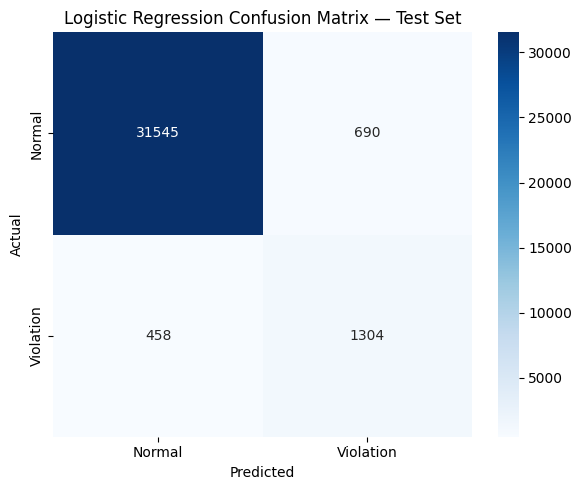

1. Confusion Matrix (Test) saved.


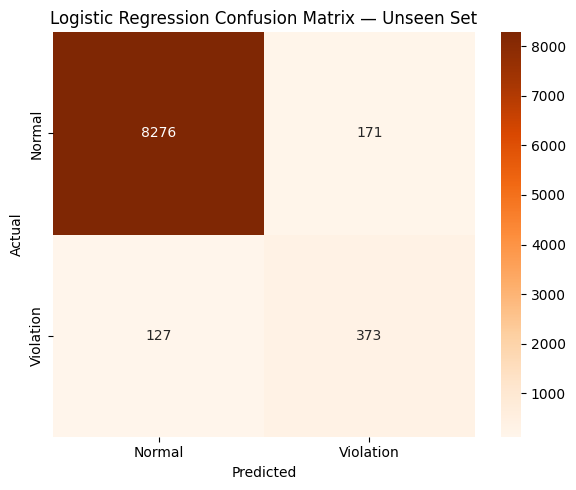

2. Confusion Matrix (Unseen) saved.


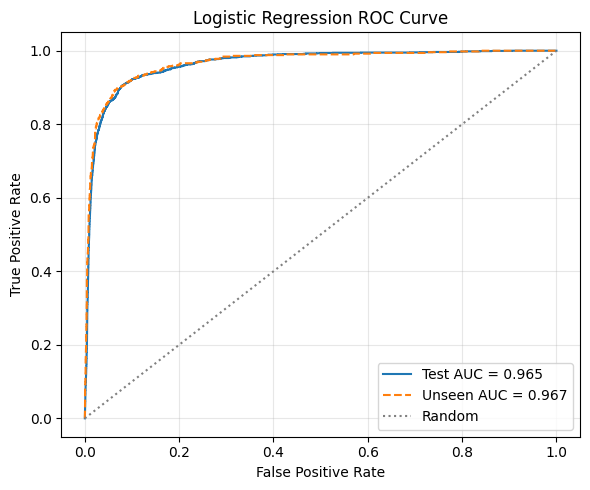

3. ROC Curve saved.


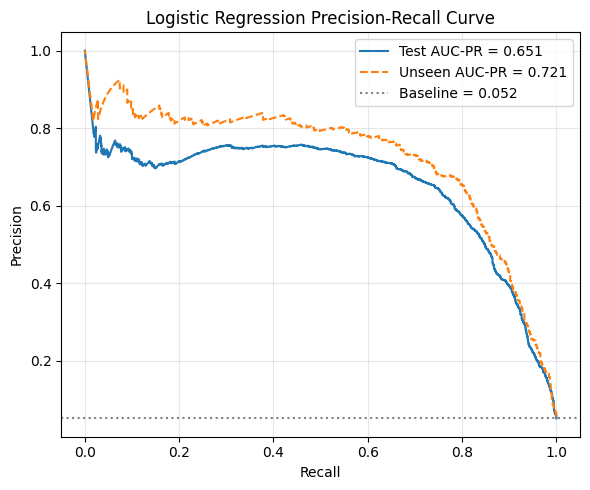

4. Precision-Recall Curve saved.


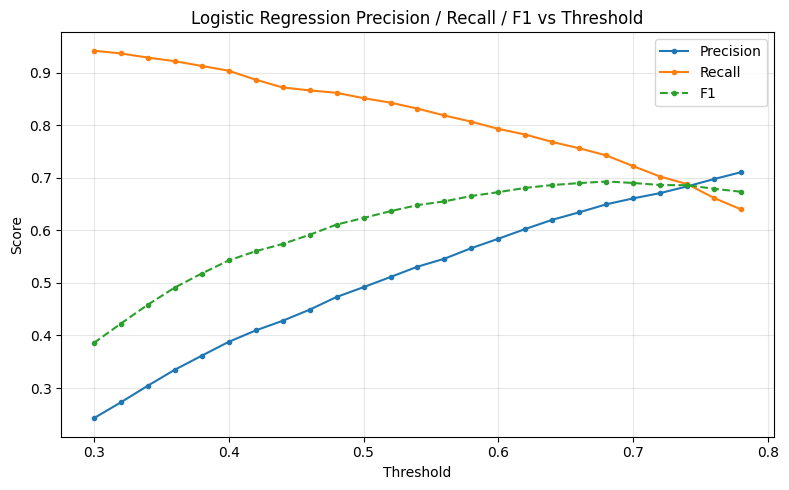

5. Threshold Metrics saved.


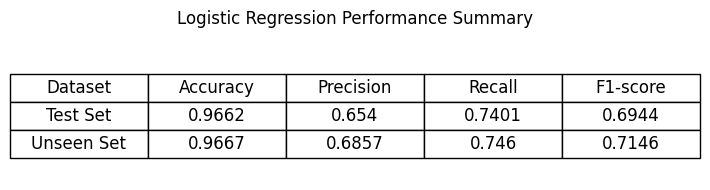

6. Performance Summary saved.

All graphs saved to: /kaggle/working/LR_results

Files saved:
  lr_confusion_matrix_test.png  —  42.19 KB
  lr_confusion_matrix_unseen.png  —  43.55 KB
  lr_performance_summary.png  —  32.95 KB
  lr_precision_recall_curve.png  —  64.81 KB
  lr_roc_curve.png  —  61.83 KB
  lr_threshold_metrics.png  —  71.49 KB


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# =================================================
# SETUP
# =================================================

save_path = "/kaggle/working/LR_results"
os.makedirs(save_path, exist_ok=True)


# =================================================
# 1. CONFUSION MATRIX — Test Set
# =================================================

cm_test = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal', 'Violation'],
    yticklabels=['Normal', 'Violation']
)

plt.title("Logistic Regression Confusion Matrix — Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

plt.savefig(f"{save_path}/lr_confusion_matrix_test.png", dpi=150)
plt.show()

print("1. Confusion Matrix (Test) saved.")


# =================================================
# 2. CONFUSION MATRIX — Unseen Set
# =================================================

cm_unseen = confusion_matrix(y_unseen, y_pred_unseen)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_unseen, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Normal', 'Violation'],
    yticklabels=['Normal', 'Violation']
)

plt.title("Logistic Regression Confusion Matrix — Unseen Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

plt.savefig(f"{save_path}/lr_confusion_matrix_unseen.png", dpi=150)
plt.show()

print("2. Confusion Matrix (Unseen) saved.")


# =================================================
# 3. ROC CURVE
# =================================================

fpr_t, tpr_t, _ = roc_curve(y_test, y_prob_test)
fpr_u, tpr_u, _ = roc_curve(y_unseen, y_prob_unseen)

auc_t = auc(fpr_t, tpr_t)
auc_u = auc(fpr_u, tpr_u)

plt.figure(figsize=(6, 5))

plt.plot(fpr_t, tpr_t, label=f"Test AUC = {auc_t:.3f}")
plt.plot(fpr_u, tpr_u, linestyle="--", label=f"Unseen AUC = {auc_u:.3f}")
plt.plot([0, 1], [0, 1], linestyle=":", color="gray", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(f"{save_path}/lr_roc_curve.png", dpi=150)
plt.show()

print("3. ROC Curve saved.")


# =================================================
# 4. PRECISION-RECALL CURVE
# =================================================

pre_t, rec_t, _ = precision_recall_curve(y_test, y_prob_test)
pre_u, rec_u, _ = precision_recall_curve(y_unseen, y_prob_unseen)

pr_auc_t = average_precision_score(y_test, y_prob_test)
pr_auc_u = average_precision_score(y_unseen, y_prob_unseen)

plt.figure(figsize=(6, 5))

plt.plot(rec_t, pre_t, label=f"Test AUC-PR = {pr_auc_t:.3f}")
plt.plot(rec_u, pre_u, linestyle="--", label=f"Unseen AUC-PR = {pr_auc_u:.3f}")

plt.axhline(
    y_test.mean(),
    linestyle=":",
    color="gray",
    label=f"Baseline = {y_test.mean():.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Logistic Regression Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(f"{save_path}/lr_precision_recall_curve.png", dpi=150)
plt.show()

print("4. Precision-Recall Curve saved.")


# =================================================
# 5. PRECISION / RECALL / F1 vs THRESHOLD
# =================================================

thresholds_plot = np.arange(0.30, 0.80, 0.02)

p_list = []
r_list = []
f_list = []

for t in thresholds_plot:

    preds = (y_prob_test >= t).astype(int)

    p_list.append(precision_score(y_test, preds, zero_division=0))
    r_list.append(recall_score(y_test, preds, zero_division=0))
    f_list.append(f1_score(y_test, preds, zero_division=0))

plt.figure(figsize=(8, 5))

plt.plot(thresholds_plot, p_list, marker='.', label="Precision")
plt.plot(thresholds_plot, r_list, marker='.', label="Recall")
plt.plot(thresholds_plot, f_list, marker='.', linestyle="--", label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Logistic Regression Precision / Recall / F1 vs Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(f"{save_path}/lr_threshold_metrics.png", dpi=150)
plt.show()

print("5. Threshold Metrics saved.")


# =================================================
# 6. PERFORMANCE SUMMARY TABLE
# =================================================

summary_df = pd.DataFrame({

    "Dataset": ["Test Set", "Unseen Set"],

    "Accuracy": [
        round(accuracy_score(y_test, y_pred_test), 4),
        round(accuracy_score(y_unseen, y_pred_unseen), 4)
    ],

    "Precision": [
        round(precision_score(y_test, y_pred_test), 4),
        round(precision_score(y_unseen, y_pred_unseen), 4)
    ],

    "Recall": [
        round(recall_score(y_test, y_pred_test), 4),
        round(recall_score(y_unseen, y_pred_unseen), 4)
    ],

    "F1-score": [
        round(f1_score(y_test, y_pred_test), 4),
        round(f1_score(y_unseen, y_pred_unseen), 4)
    ]
})

fig, ax = plt.subplots(figsize=(8, 2))

ax.axis('off')

table = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 2)

plt.title("Logistic Regression Performance Summary", pad=20)
plt.tight_layout()

plt.savefig(f"{save_path}/lr_performance_summary.png", dpi=150)
plt.show()

print("6. Performance Summary saved.")


# =================================================
# 7. FINISHED
# =================================================

print("\nAll graphs saved to:", save_path)

print("\nFiles saved:")

for f in sorted(os.listdir(save_path)):

    size = os.path.getsize(f"{save_path}/{f}")

    print(f"  {f}  —  {round(size/1024, 2)} KB")